<a href="https://colab.research.google.com/github/EnricoABM/umc-ia/blob/main/SVC_x_LinearSVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Enrico de Andrade Bertozzi Miranda RGM: 11231100657

Nome: Edson Miguel Junior RGM: 11231504431

Curso: Engenharia de Software

Disciplina: Inteligência Artificial

Turma: 6º A Matutina

Professor: Dr. Fabiano Bezerra Menegidio


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC, LinearSVC

import time

RANDOM_STATE = 42

# Carregamento do Dataset

In [52]:
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [53]:
round(df.describe(), 2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# Separação dos dados

In [55]:
# Separação dos dados

X = df.drop('Outcome', axis=1)
Y = df['Outcome']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

print(f'Total: {X.shape} - {Y.shape}')
print(f'Treino: {X_train.shape} - {Y_train.shape}')
print(f'Total: {X_test.shape} - {Y_test.shape}')


Total: (768, 8) - (768,)
Treino: (614, 8) - (614,)
Total: (154, 8) - (154,)


# Treino dos modelos

## SVC com kernel linear

In [69]:
# Treino do modelo

time_init = time.perf_counter()

svc = SVC(kernel='linear', random_state=RANDOM_STATE)

svc.fit(X_train, Y_train)

Y_pred_svc = svc.predict(X_test)

time_end = time.perf_counter()

time_exec = time_end - time_init

Acurácia: 75.32%
Tempo de execução: 5.13 segundos


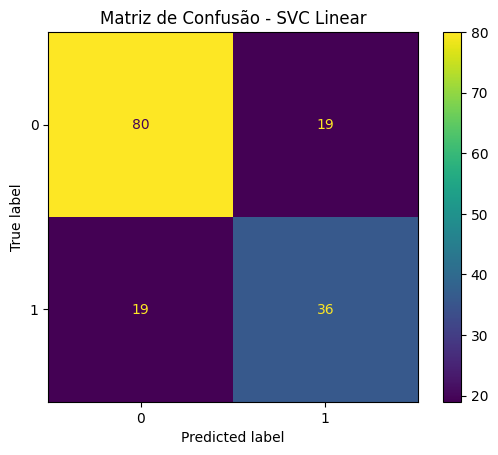

In [71]:
# Métricas do modelo

acc = accuracy_score(Y_test, Y_pred_svc)

print(f'Acurácia: {acc*100:.2f}%')
print(f'Tempo de execução: {time_exec:.2f} segundos')
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred_svc, labels=[0, 1])
plt.title("Matriz de Confusão - SVC Linear")
plt.show()

## LinearSVC

In [77]:
# Treino do modelo

time_init = time.perf_counter()

lsvc = LinearSVC(random_state=RANDOM_STATE)

lsvc.fit(X_train, Y_train)

Y_pred_lsvc = lsvc.predict(X_test)

time_end = time.perf_counter()

time_exec = time_end - time_init

Acurácia: 76.62%
Tempo de execução: 11.16 milissegundos


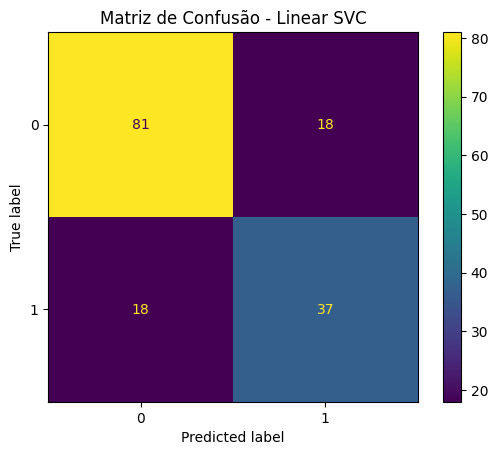

In [78]:
# Métricas do modelo

acc = accuracy_score(Y_test, Y_pred_lsvc)

print(f'Acurácia: {acc*100:.2f}%')
print(f'Tempo de execução: {time_exec*1000:.2f} milissegundos')
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred_lsvc)
plt.title('Matriz de Confusão - Linear SVC')
plt.show()

# Relatório

1. Houve diferença de acurácia entre os dois modelos? E no tempo de execução?

> Sim.

| Modelo | Acurácia | Tempo de Execução |
|--------|----------|-------------------|
| SVC | 75,32% | 5 segundos |
| Linear | 76,62% | 12 milissegundos |

2. Qual a diferença conceitual entre SVC(kernel="linear") (libsvm) e LinearSVC (liblinear)?

> A principal diferença entre os dois modelos está na **função de perda** e no 'handling of intercept regularization' implementados por padrão.

3. Como o parâmetro C influencia os dois modelos?

> No modelo LinearSVC utiliza um gerador de números aleatórios enquanto está treinando o modelo, criando pequenas variações no resultado em comparação ao SVC.

4. Por que o LinearSVC não fornece probabilidades (predict_proba)?

> O LinearSVC prioriza a eficiência e otimização, em detrimento de algumas etapas, como é o caso das probabilidades

5. Em um cenário com datasets muito grandes, qual seria mais adequado? Por quê?

> LinearSVC, além da otimização do modelo, a sua biblioteca padrão é específica para grande conjuntos de dados.

6. Se vocês fossem publicar um artigo com esse dataset, qual modelo escolheriam? Justifiquem.

> A escolha do modelo depende do tamanho do dataset e do objetivo da pesquisa. Para grandes volumes de dados, o LinearSVC seria preferido pela eficiência. No entanto, testar o SVC com kernels não lineares também seria importante, caso o problema exija uma separação mais complexa.